# Notebook 06 — Feature Matrix + Modelos Tuneados

## Objetivo

Este notebook hace dos cosas, en orden:

1. Construye la `feature_matrix.csv` (técnicas + macro + sentiment)
2. Entrena XGBoost y MLP con **hiperparámetros óptimos** encontrados mediante walk-forward expanding window + Bayesian search (Optuna TPE), y los guarda como `xgboost_tuned` / `mlp_tuned`.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from src import data_loader, features, sentiment, models, utils, hyperparameters

utils.set_plot_style()

RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
MODELS_DIR    = "../models"
CACHE_PATH    = f"{PROCESSED_DIR}/sentiment.csv"

FEATURE_COLS_XGBoost = [
    "return_1d", "GPRD_ACT", "return_5d", "unrate", "volume_change", "RSI_14",
    "sentiment_mean", "sentiment_std", "news_count"
]

FEATURE_COLS_MLP = [
    "RSI_14", "MACD", "BB_position", "return_1d", "return_5d", "t10y2y", "fedfunds", "cpi", "unrate", "GPRD", "GPRD_ACT", "GPRD_THREAT",
    "sentiment_mean", "sentiment_std", "news_count"
]



/Users/nacho/Documents/Ingenieria en Inteligencia Artificial/3er Año/Primer cuatrimestre/Aprendizaje Automatico y Aprendizaje Profundo/Trabajos practicos/Trabajo Practico Final/Predictor-de-direcci-n-del-S-P-500/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Construcción de la feature matrix con sentiment

Cargamos el dataset base (`sp500_features.csv`) y lo enriquecemos con el sentiment diario agregado y shifteado 1 día (notebook 04). El resultado es la `feature_matrix.csv` con las 14 features finales + la variable objetivo.

Los días sin cobertura de noticias (feriados, fines de semana donde se publicaron noticias pero el mercado no abrió, o días muy tempranos con poca cobertura) reciben `sentiment_mean=0`, `sentiment_std=0` y `news_count=0` — lo que representa neutralidad de información.

In [2]:
# Cargar datos base
sp500_features_df = pd.read_csv(f"{PROCESSED_DIR}/sp500_features.csv",
                                index_col=0, parse_dates=True)

# Cargar y agregar sentiment
news = data_loader.load_news(RAW_DIR)
raw_sent = sentiment.load_or_run_finbert(news, CACHE_PATH)
sentiment_diario = sentiment.aggregate_daily_sentiment(raw_sent)

# Construir feature matrix completa
df = features.build_feature_matrix(
    sp500_features_df,
    sentiment=sentiment_diario,
    include_sentiment=True,
    save_path=f"{PROCESSED_DIR}/feature_matrix.csv",
)

[sentiment] Cache encontrado en ../data/processed/sentiment.csv (29,323 filas). Saltando FinBERT.
[features] feature_matrix guardada en ../data/processed/feature_matrix.csv (4,613 filas).


## XGBoost

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = models.temporal_split(
    df, features=FEATURE_COLS_XGBoost, target="target"
)
X_train_xgb_s, X_val_xgb_s, X_test_xgb_s, scaler_xgb = models.scale_features(X_train, X_val, X_test)

[models] Split temporal:
  train: 4,249 muestras (2008-02-13 → 2024-12-31)
  val:   250 muestras (2025-01-02 → 2025-12-31)
  test:  114 muestras (2026-01-02 → 2026-06-16)


XGBoost — Walk-Forward Bayesian Search

Buscamos los mejores hiperparámetros para XGBoost usando walk-forward expanding window sobre los años 2020–2024, optimizando AUC-ROC promedio.

| Hiperparámetro    | Rango de búsqueda       |
|-------------------|-------------------------|
| `max_depth`       | [3, 6]                  |
| `learning_rate`   | [0.01, 0.20] log        |
| `subsample`       | [0.6, 1.0]              |
| `colsample_bytree`| [0.6, 1.0]              |
| `min_child_weight`| [1, 7]                  |
| `reg_alpha`       | [0.0, 2.0]              |
| `reg_lambda`      | [0.5, 3.0]              |
| `gamma`           | [0.0, 2.0]              |

In [4]:
best_params_xgb, study_xgb = hyperparameters.walk_forward_bayesian_search(
    df,
    features=FEATURE_COLS_XGBoost,
    target="target",
    n_trials=50,
)

Best trial: 41. Best value: 0.573137: 100%|██████████| 50/50 [00:36<00:00,  1.37it/s]


[hyperparameters] Walk-forward Bayesian search — 50 trials, 6 folds
  Mejor AUC-CV promedio: 0.5731
  Mejores parámetros:
    max_depth             : 4
    learning_rate         : 0.14064
    subsample             : 0.72493
    colsample_bytree      : 0.87861
    min_child_weight      : 7
    reg_alpha             : 0.93805
    reg_lambda            : 1.21262
    gamma                 : 0.44153


In [5]:
xgb_tuned = hyperparameters.train_xgboost_tuned(
    X_train_xgb_s, y_train, X_val_xgb_s, y_val, best_params_xgb
)

metricas_xgb = {}
for nombre, X, y in [("train", X_train_xgb_s, y_train), ("val", X_val_xgb_s, y_val), ("test", X_test_xgb_s, y_test)]:
    metricas_xgb[nombre] = models.evaluate_model(xgb_tuned, X, y, nombre)

models.save_model(xgb_tuned, scaler_xgb, "xgboost_tuned", MODELS_DIR)

[hyperparameters] XGBoost tuneado. Mejor ronda: 4

── TRAIN ──
  accuracy    : 0.5886
  f1          : 0.5891
  roc_auc     : 0.6265
  precision   : 0.5901
  recall      : 0.5886

── VAL ──
  accuracy    : 0.568
  f1          : 0.566
  roc_auc     : 0.6011
  precision   : 0.5647
  recall      : 0.568

── TEST ──
  accuracy    : 0.4912
  f1          : 0.4783
  roc_auc     : 0.5078
  precision   : 0.476
  recall      : 0.4912
[models] xgboost_tuned guardado en ../models/


## MLP — Walk-Forward Bayesian Search

Buscamos los mejores hiperparámetros para MLP usando walk-forward expanding window sobre los años 2020–2024, optimizando AUC-ROC promedio.

| Hiperparámetro       | Rango de búsqueda                              |
|----------------------|------------------------------------------------|
| `hidden_layer_sizes` | [(32, )(64,), (128,64), (256,128), (256,128,64)]     |
| `learning_rate_init` | [1e-4, 1e-2] log                               |
| `alpha` (L2)         | [1e-5, 1e-1] log                               |
| `activation`         | ['relu', 'tanh']                               |

El scaler se fitea dentro de cada fold para evitar data leakage en la normalización.

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test = models.temporal_split(
    df, features=FEATURE_COLS_MLP, target="target"
)
X_train_mlp_s, X_val_mlp_s, X_test_mlp_s, scaler_mlp = models.scale_features(X_train, X_val, X_test)

[models] Split temporal:
  train: 4,249 muestras (2008-02-13 → 2024-12-31)
  val:   250 muestras (2025-01-02 → 2025-12-31)
  test:  114 muestras (2026-01-02 → 2026-06-16)


In [7]:
best_params_mlp, study_mlp = hyperparameters.walk_forward_bayesian_search_mlp(
    df,
    features=FEATURE_COLS_MLP,
    target="target",
    n_trials=50,
)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/nacho/Documents/Ingenieria en Inteligencia Artificial/3er Año/Primer cuatrimestre/Aprendizaje Automatico y Aprendizaje Profundo/Trabajos practicos/Trabajo Practico Final/Predictor-de-direcci-n-del-S-P-500/notebooks/../src/hyperparameters.py:185: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32,) which is of type tuple.
  hidden = trial.suggest_categorical(
/Users/nacho/Documents/Ingenieria en Inteligencia Artificial/3er Año/Primer cuatrimestre/Aprendizaje Automatico y Aprendizaje Profundo/Trabajos practicos/Trabajo Practico Final/Predictor-de-direcci-n-del-S-P-500/notebooks/../src/hyperparameters.py:185: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  hidden = trial.suggest_categorical(
/Users/nacho/Documents/Ingenieria en I


[hyperparameters] Walk-forward Bayesian search MLP — 50 trials, 5 folds
  Mejor AUC-CV promedio: 0.5376
  Mejores parámetros:
    hidden_layer_sizes    : (64,)
    activation            : tanh
    learning_rate_init    : 0.00268
    alpha                 : 7e-05


In [8]:
mlp_tuned = hyperparameters.train_mlp_tuned(X_train_mlp_s, y_train, best_params_mlp)

metricas_mlp = {}
for nombre, X, y in [("train", X_train_mlp_s, y_train), ("val", X_val_mlp_s, y_val), ("test", X_test_mlp_s, y_test)]:
    metricas_mlp[nombre] = models.evaluate_model(mlp_tuned, X, y, nombre)

models.save_model(mlp_tuned, scaler_mlp, "mlp_tuned", MODELS_DIR)

[hyperparameters] MLP tuneado. Épocas: 19

── TRAIN ──
  accuracy    : 0.5526
  f1          : 0.4829
  roc_auc     : 0.5423
  precision   : 0.5462
  recall      : 0.5526

── VAL ──
  accuracy    : 0.572
  f1          : 0.5274
  roc_auc     : 0.5193
  precision   : 0.5458
  recall      : 0.572

── TEST ──
  accuracy    : 0.4825
  f1          : 0.4818
  roc_auc     : 0.4613
  precision   : 0.4813
  recall      : 0.4825
[models] mlp_tuned guardado en ../models/


## Comparación: XGBoost Tuned vs MLP Tuned

Comparamos los dos modelos tuneados. Métricas principales: AUC-ROC (métrica de ranking, insensible al desbalance) y F1-score.

In [9]:
filas = [
    {"Modelo": "XGBoost Tuned", "Split": s, **{k: v for k, v in m.items() if k != "split"}}
    for s, m in metricas_xgb.items()
]

if metricas_mlp is not None:
    filas += [
        {"Modelo": "MLP Tuned", "Split": s, **{k: v for k, v in m.items() if k != "split"}}
        for s, m in metricas_mlp.items()
    ]

tabla = pd.DataFrame(filas)
print("Comparación de modelos tuneados:")
display(tabla.set_index(["Modelo", "Split"]))

Comparación de modelos tuneados:


accuracy      f1  roc_auc  precision  recall
Modelo        Split                                              
XGBoost Tuned train    0.5886  0.5891   0.6265     0.5901  0.5886
              val      0.5680  0.5660   0.6011     0.5647  0.5680
              test     0.4912  0.4783   0.5078     0.4760  0.4912
MLP Tuned     train    0.5526  0.4829   0.5423     0.5462  0.5526
              val      0.5720  0.5274   0.5193     0.5458  0.5720
              test     0.4825  0.4818   0.4613     0.4813  0.4825

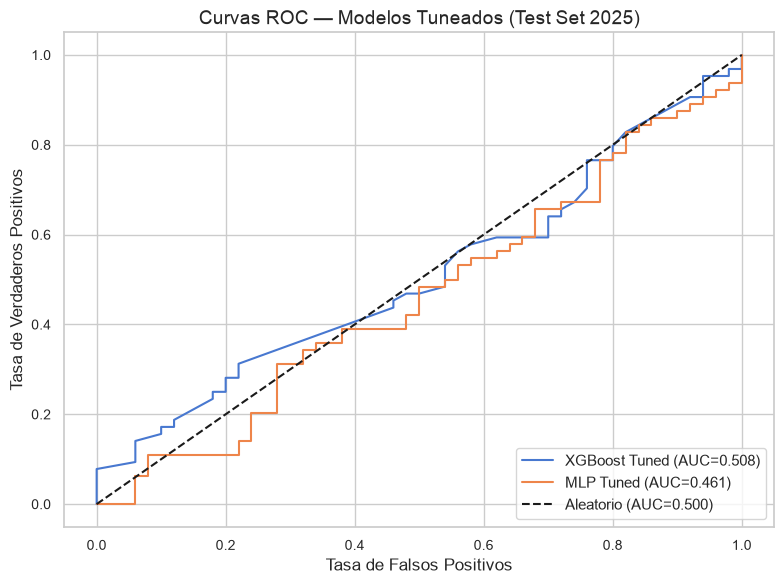

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

modelos_roc = [("XGBoost Tuned", xgb_tuned, X_test_xgb_s, y_test)]
if mlp_tuned is not None:
    modelos_roc.append(("MLP Tuned", mlp_tuned, X_test_mlp_s, y_test))

for label, modelo, X, y in modelos_roc:
    y_score = modelo.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_score)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC=0.500)")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Modelos Tuneados (Test Set 2025)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()